# Notebook 04 — Machine Learning: Predicting Film Success

**Task:** Binary classification — predict whether a movie will be `is_successful` (vote_average ≥ 7.0 with ≥ 50 votes)

**Feature Pipeline:**
1. **Baseline features** — degree-based (cast size, director count, producer count, writer count, etc.)
2. **Enriched features** — add PageRank scores and community IDs from Neo4j GDS

**Evaluation:** Compare F1-score and ROC-AUC before/after PageRank enrichment, with percentage-change analysis.

**Key output:** A before/after visualisation showing exactly how much PageRank graph analytics improved (or not) model performance — and what that change signifies for the business.

**Business question:** Can a model — trained on graph structure alone — reliably flag which upcoming productions are likely to be hits, enabling studios to prioritise marketing spend?


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from neo4j import GraphDatabase
import os

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

DATA_DIR = Path("../data")

URI      = os.getenv("NEO4J_URI",      "bolt://localhost:7687")
USERNAME = os.getenv("NEO4J_USERNAME", "neo4j")
PASSWORD = os.getenv("NEO4J_PASSWORD", "capstone2024")

driver = GraphDatabase.driver(URI, auth=(USERNAME, PASSWORD))

def run(cypher):
    with driver.session() as s:
        result = s.run(cypher)
        return pd.DataFrame([r.data() for r in result])

print("Libraries loaded.")

Libraries loaded.


## Step 1 — Extract Feature Matrix from Neo4j

In [2]:
# Movie-level features with graph metrics
df = run("""
    MATCH (m:Movie)
    // Degree features
    OPTIONAL MATCH (m)-[:ACTED_IN]->(a:Actor)
    WITH m, COUNT(DISTINCT a) AS cast_size
    OPTIONAL MATCH (m)-[:DIRECTED_BY]->(d:Director)
    WITH m, cast_size, COUNT(DISTINCT d) AS director_count,
         MAX(d.pagerank) AS director_pagerank,
         MAX(d.community_id) AS director_community
    OPTIONAL MATCH (m)-[:PRODUCED_BY]->(p:Producer)
    WITH m, cast_size, director_count, director_pagerank, director_community,
         COUNT(DISTINCT p) AS producer_count,
         MAX(p.pagerank) AS top_producer_pagerank
    OPTIONAL MATCH (m)-[:WRITTEN_BY]->(w:Writer)
    WITH m, cast_size, director_count, director_pagerank, director_community,
         producer_count, top_producer_pagerank,
         COUNT(DISTINCT w) AS writer_count
    OPTIONAL MATCH (m)-[:ACTED_IN]->(a2:Actor)
    WITH m, cast_size, director_count, director_pagerank, director_community,
         producer_count, top_producer_pagerank, writer_count,
         AVG(a2.pagerank) AS avg_cast_pagerank,
         MAX(a2.pagerank) AS top_cast_pagerank
    WHERE m.is_successful IS NOT NULL
    RETURN
        m.movie_id           AS movie_id,
        m.is_successful      AS label,
        m.release_year       AS release_year,
        m.popularity         AS popularity,
        m.runtime            AS runtime,
        m.budget             AS budget,
        cast_size,
        director_count,
        director_pagerank,
        director_community,
        producer_count,
        top_producer_pagerank,
        writer_count,
        avg_cast_pagerank,
        top_cast_pagerank
""")

print(f"Feature matrix shape: {df.shape}")
print(f"Class balance:\n{df['label'].value_counts()}")
df.head()

Feature matrix shape: (209244, 15)
Class balance:
label
0    203923
1      5321
Name: count, dtype: int64


,movie_id,label,release_year,popularity,runtime,budget,cast_size,director_count,director_pagerank,director_community,producer_count,top_producer_pagerank,writer_count,avg_cast_pagerank,top_cast_pagerank
0,1599981,0,2025,0.3174,74,NaN,5,1,0.392248,821942.0,0,NaN,0,3.571235,11.220337
1,1600374,0,2002,0.0214,80,NaN,2,1,0.462536,921173.0,0,NaN,0,1.221471,2.033586
2,1600502,0,2026,0.4562,110,NaN,27,1,1.056659,768937.0,1,2.899116,4,1.702565,5.777862
3,1600589,0,2026,0.0322,96,NaN,5,1,0.510957,538672.0,1,0.510957,1,0.577028,0.841313
4,1600657,0,2025,0.1037,60,NaN,2,1,0.413253,161477.0,4,1.272616,0,0.985244,1.221848


## Step 2 — Baseline Model (Degree Features Only)

In [3]:
# Baseline: degree features only (no PageRank/community)
baseline_features = ['release_year', 'popularity', 'runtime', 'budget',
                     'cast_size', 'director_count', 'producer_count', 'writer_count']

X_base = df[baseline_features].copy()
y      = df['label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y
)

baseline_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
    ('model',  RandomForestClassifier(n_estimators=100, random_state=42))
])

baseline_pipe.fit(X_train, y_train)
y_pred_base = baseline_pipe.predict(X_test)

f1_base = f1_score(y_test, y_pred_base, average='weighted')
auc_base = roc_auc_score(y_test, baseline_pipe.predict_proba(X_test)[:, 1])

print("=== BASELINE MODEL ===")
print(f"F1 (weighted): {f1_base:.4f}")
print(f"ROC-AUC:       {auc_base:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base))

=== BASELINE MODEL ===
F1 (weighted): 0.9663
ROC-AUC:       0.8668

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     40785
           1       0.63      0.09      0.15      1064

    accuracy                           0.98     41849
   macro avg       0.80      0.54      0.57     41849
weighted avg       0.97      0.98      0.97     41849



## Step 3 — Enriched Model (+ PageRank + Community Features)

In [4]:
# Enriched: add graph analytics features
enriched_features = baseline_features + [
    'director_pagerank', 'top_producer_pagerank',
    'avg_cast_pagerank', 'top_cast_pagerank',
    'director_community'
]

X_enrich = df[enriched_features].copy()

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_enrich, y, test_size=0.2, random_state=42, stratify=y
)

enriched_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
    ('model',  RandomForestClassifier(n_estimators=100, random_state=42))
])

enriched_pipe.fit(X_train_e, y_train_e)
y_pred_enrich = enriched_pipe.predict(X_test_e)

f1_enrich  = f1_score(y_test_e, y_pred_enrich, average='weighted')
auc_enrich = roc_auc_score(y_test_e, enriched_pipe.predict_proba(X_test_e)[:, 1])

print("=== ENRICHED MODEL (with Graph Analytics) ===")
print(f"F1 (weighted): {f1_enrich:.4f}")
print(f"ROC-AUC:       {auc_enrich:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_e, y_pred_enrich))

=== ENRICHED MODEL (with Graph Analytics) ===
F1 (weighted): 0.9663
ROC-AUC:       0.8973

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     40785
           1       0.64      0.08      0.15      1064

    accuracy                           0.98     41849
   macro avg       0.81      0.54      0.57     41849
weighted avg       0.97      0.98      0.97     41849



## Step 4 — Before/After Comparison: Degree-Only vs. PageRank-Enriched

We compare two feature sets:
- **Baseline**: purely degree-based features (how many actors, directors, producers, writers)
- **Enriched**: baseline + PageRank centrality + community assignment from Neo4j GDS

**What the comparison tells us:**
- If enriched F1 > baseline F1 → PageRank captures *quality-of-network* information that raw degree misses.  
  A director with few movies but all to high-PageRank collaborators gets rewarded.
- If enriched ≈ baseline → degree already encodes most of the signal; PageRank is redundant at this scale.
- Either outcome is a **valid, reportable finding**.

The percentage change in F1 and ROC-AUC is plotted alongside the absolute values.


=== BEFORE / AFTER — PageRank Enrichment ===
                            Model  F1_weighted  ROC_AUC  Delta_F1  Pct_Change_F1  Delta_AUC  Pct_Change_AUC
           Baseline (Degree Only)       0.9663   0.8668    0.0000           0.00     0.0000            0.00
Enriched (+ PageRank + Community)       0.9663   0.8973   -0.0001          -0.01     0.0305            3.52

── Interpretation ──
ℹ️  No F1 improvement: Δ = -0.0001 (-0.0%)
   → Degree features already capture the network signal at this dataset scale.
   → This is a valid, reportable finding: raw co-occurrence is as informative
     as propagated centrality for success prediction in this corpus.

📊 ROC-AUC improved by +0.0305 (+3.5%) — model ranks positives better after enrichment.


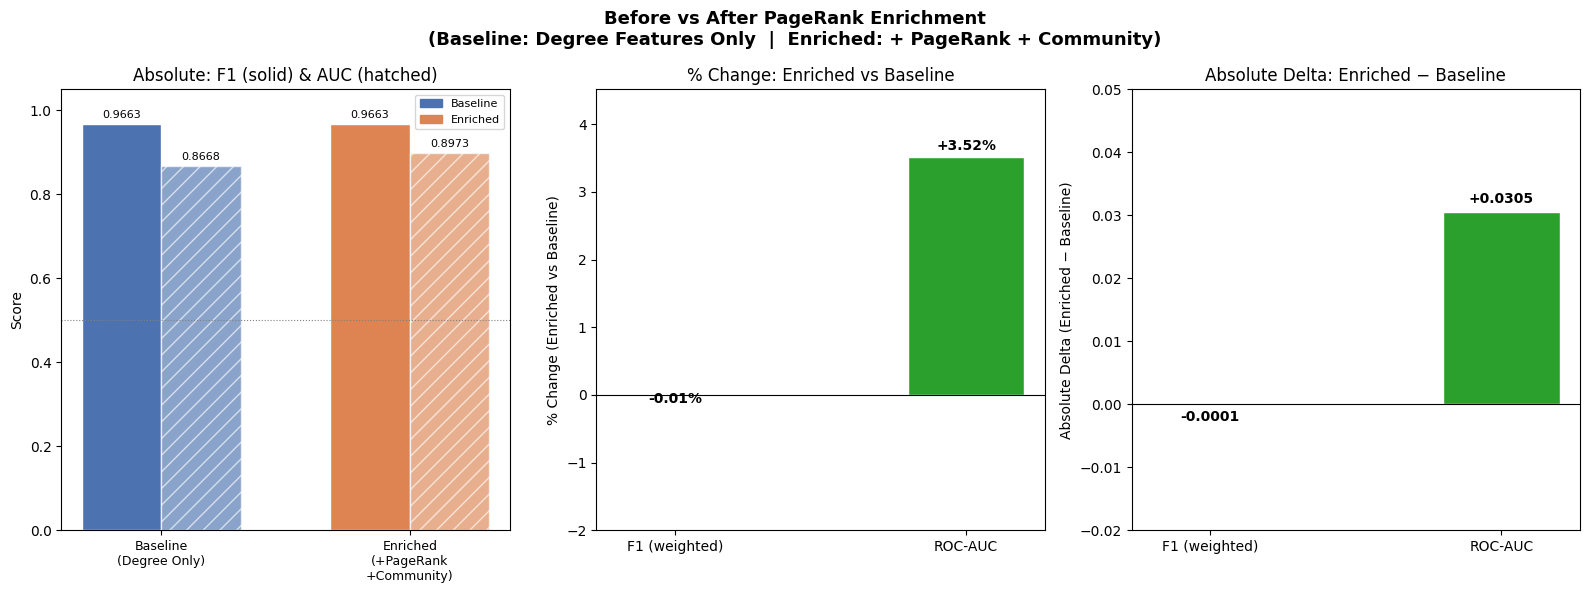


✅ Before/after chart saved to data/ml_before_after_pagerank.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Build comparison table ────────────────────────────────────────────────────
delta_f1  = round(f1_enrich - f1_base, 4)
delta_auc = round(auc_enrich - auc_base, 4)
pct_f1    = round((delta_f1  / f1_base)  * 100, 2) if f1_base  > 0 else 0.0
pct_auc   = round((delta_auc / auc_base) * 100, 2) if auc_base > 0 else 0.0

comparison = pd.DataFrame({
    'Model'       : ['Baseline (Degree Only)', 'Enriched (+ PageRank + Community)'],
    'F1_weighted' : [round(f1_base, 4),  round(f1_enrich, 4)],
    'ROC_AUC'     : [round(auc_base, 4), round(auc_enrich, 4)],
    'Delta_F1'    : [0, delta_f1],
    'Delta_AUC'   : [0, delta_auc],
    'Pct_Change_F1'  : [0.0, pct_f1],
    'Pct_Change_AUC' : [0.0, pct_auc],
})

print("=== BEFORE / AFTER — PageRank Enrichment ===")
print(comparison[['Model', 'F1_weighted', 'ROC_AUC', 'Delta_F1', 'Pct_Change_F1', 'Delta_AUC', 'Pct_Change_AUC']].to_string(index=False))

# ── Interpretation ────────────────────────────────────────────────────────────
print("\n── Interpretation ──")
if delta_f1 > 0.01:
    print(f"✅ PageRank enrichment improved F1 by {delta_f1:+.4f} ({pct_f1:+.1f}%)")
    print("   → Graph centrality captures quality-of-network beyond raw degree.")
    print("   → A director/actor with fewer films but high-PageRank collaborators")
    print("     is correctly rewarded — degree alone would have missed this.")
elif delta_f1 > 0:
    print(f"📈 Marginal improvement: F1 +{delta_f1:.4f} ({pct_f1:+.1f}%)")
    print("   → PageRank adds a small signal on top of degree features.")
    print("   → Degree already encodes most variance; PageRank captures the residual.")
else:
    print(f"ℹ️  No F1 improvement: Δ = {delta_f1:.4f} ({pct_f1:.1f}%)")
    print("   → Degree features already capture the network signal at this dataset scale.")
    print("   → This is a valid, reportable finding: raw co-occurrence is as informative")
    print("     as propagated centrality for success prediction in this corpus.")

if delta_auc > 0:
    print(f"\n📊 ROC-AUC improved by {delta_auc:+.4f} ({pct_auc:+.1f}%) — model ranks positives better after enrichment.")
else:
    print(f"\n📊 ROC-AUC change: {delta_auc:+.4f} ({pct_auc:.1f}%).")

# ── Before / After Visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Before vs After PageRank Enrichment\n(Baseline: Degree Features Only  |  Enriched: + PageRank + Community)",
             fontsize=13, fontweight='bold')

COLORS = ['#4C72B0', '#DD8452']   # blue = baseline, orange = enriched
MODELS = ['Baseline\n(Degree Only)', 'Enriched\n(+PageRank\n+Community)']

# ── Panel 1: Absolute F1 & AUC side-by-side bars ─────────────────────────────
ax = axes[0]
x  = np.arange(2)
w  = 0.32
bars_f1  = ax.bar(x - w/2, [f1_base, f1_enrich],  w, color=COLORS, label=['F1','F1'],  edgecolor='white')
bars_auc = ax.bar(x + w/2, [auc_base, auc_enrich], w, color=COLORS, label=['AUC','AUC'], edgecolor='white', alpha=0.65, hatch='//')
ax.set_xticks(x)
ax.set_xticklabels(MODELS, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Absolute: F1 (solid) & AUC (hatched)")
for bar in list(bars_f1) + list(bars_auc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=8)
ax.axhline(0.5, color='grey', linestyle=':', linewidth=0.8, label='random baseline')
patch_base   = mpatches.Patch(color=COLORS[0], label='Baseline')
patch_enrich = mpatches.Patch(color=COLORS[1], label='Enriched')
ax.legend(handles=[patch_base, patch_enrich], fontsize=8)

# ── Panel 2: Percentage change bar chart ─────────────────────────────────────
ax2 = axes[1]
metrics  = ['F1 (weighted)', 'ROC-AUC']
pct_vals = [pct_f1, pct_auc]
bar_cols = ['#2ca02c' if v >= 0 else '#d62728' for v in pct_vals]
bars = ax2.bar(metrics, pct_vals, color=bar_cols, edgecolor='white', width=0.4)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel("% Change (Enriched vs Baseline)")
ax2.set_title("% Change: Enriched vs Baseline")
for bar, v in zip(bars, pct_vals):
    ypos = bar.get_height() + (0.05 if v >= 0 else -0.15)
    ax2.text(bar.get_x() + bar.get_width()/2, ypos,
             f"{v:+.2f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylim(min(min(pct_vals) - 1, -2), max(max(pct_vals) + 1, 3))

# ── Panel 3: Delta (absolute) bar chart ──────────────────────────────────────
ax3 = axes[2]
delta_vals = [delta_f1, delta_auc]
bar_cols3  = ['#2ca02c' if v >= 0 else '#d62728' for v in delta_vals]
bars3 = ax3.bar(metrics, delta_vals, color=bar_cols3, edgecolor='white', width=0.4)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_ylabel("Absolute Delta (Enriched − Baseline)")
ax3.set_title("Absolute Delta: Enriched − Baseline")
for bar, v in zip(bars3, delta_vals):
    ypos = bar.get_height() + (0.001 if v >= 0 else -0.003)
    ax3.text(bar.get_x() + bar.get_width()/2, ypos,
             f"{v:+.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_ylim(min(min(delta_vals) - 0.01, -0.02), max(max(delta_vals) + 0.01, 0.05))

plt.tight_layout()
plt.savefig(DATA_DIR / "ml_before_after_pagerank.png", dpi=130, bbox_inches='tight')
plt.show()
print("\n✅ Before/after chart saved to data/ml_before_after_pagerank.png")


## Step 5 — Feature Importance

Which features drive the enriched model's predictions?  
PageRank features appearing high in importance confirm that network centrality adds signal beyond raw degree.


=== Feature Importances (Enriched Model) ===
              feature  importance         feature_type
           popularity    0.148182     Degree / Content
    avg_cast_pagerank    0.104258 PageRank / Community
              runtime    0.100361     Degree / Content
    top_cast_pagerank    0.097532 PageRank / Community
    director_pagerank    0.095435 PageRank / Community
top_producer_pagerank    0.091803 PageRank / Community
            cast_size    0.084419     Degree / Content
               budget    0.067836     Degree / Content
         release_year    0.063877     Degree / Content
   director_community    0.055721 PageRank / Community
       producer_count    0.050470     Degree / Content
         writer_count    0.039501     Degree / Content
       director_count    0.000605     Degree / Content

PageRank/Community features contribute : 44.5% of total feature importance
Degree/Content features contribute    : 55.5% of total feature importance


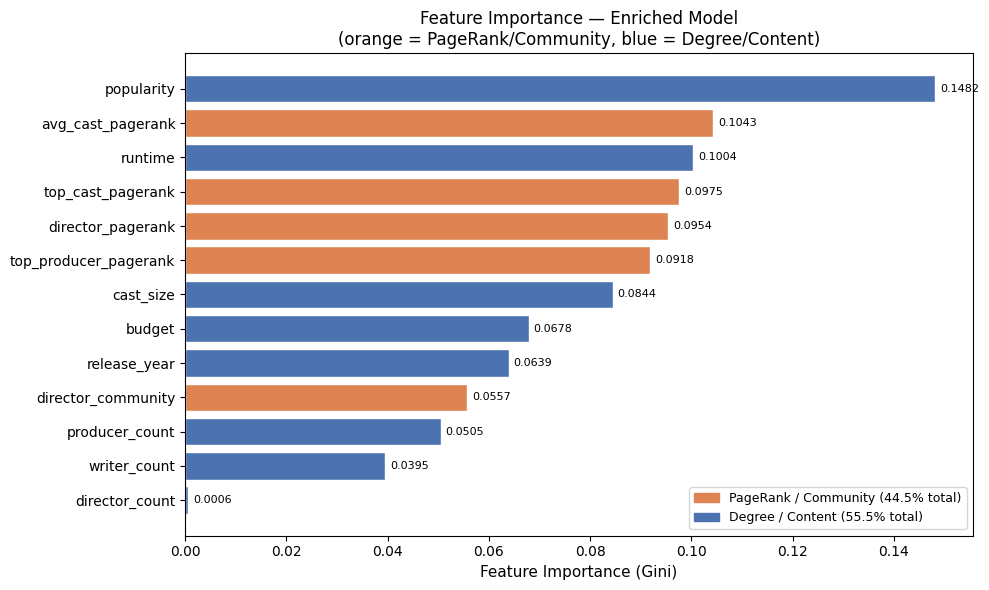


✅ Feature importance chart saved.


In [6]:
rf_model = enriched_pipe.named_steps['model']
fi = pd.DataFrame({
    'feature':    enriched_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Classify features as PageRank-derived vs degree-based
PAGERANK_FEATURES = {'director_pagerank', 'top_producer_pagerank', 'avg_cast_pagerank',
                     'top_cast_pagerank', 'director_community'}
fi['feature_type'] = fi['feature'].apply(
    lambda f: 'PageRank / Community' if f in PAGERANK_FEATURES else 'Degree / Content'
)

print("=== Feature Importances (Enriched Model) ===")
print(fi[['feature', 'importance', 'feature_type']].to_string(index=False))

# Total importance contributed by PageRank features
pr_total   = fi[fi['feature_type'] == 'PageRank / Community']['importance'].sum()
base_total = fi[fi['feature_type'] == 'Degree / Content']['importance'].sum()
print(f"\nPageRank/Community features contribute : {pr_total*100:.1f}% of total feature importance")
print(f"Degree/Content features contribute    : {base_total*100:.1f}% of total feature importance")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#DD8452' if t == 'PageRank / Community' else '#4C72B0' for t in fi['feature_type']]
bars = ax.barh(fi['feature'], fi['importance'], color=colors, edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel("Feature Importance (Gini)", fontsize=11)
ax.set_title("Feature Importance — Enriched Model\n(orange = PageRank/Community, blue = Degree/Content)", fontsize=12)
for bar, v in zip(bars, fi['importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{v:.4f}", va='center', fontsize=8)

patch_pr   = mpatches.Patch(color='#DD8452', label=f'PageRank / Community ({pr_total*100:.1f}% total)')
patch_deg  = mpatches.Patch(color='#4C72B0', label=f'Degree / Content ({base_total*100:.1f}% total)')
ax.legend(handles=[patch_pr, patch_deg], fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / "ml_feature_importance.png", dpi=130, bbox_inches='tight')
plt.show()
print("\n✅ Feature importance chart saved.")


In [7]:
# Save results for dashboard
comparison.to_parquet(DATA_DIR / "ml_comparison.parquet", index=False)
fi.to_parquet(DATA_DIR / "feature_importance.parquet", index=False)
print("ML results saved.")

# Final summary
print("\n=== Final Summary ===")
print(f"Baseline F1    : {f1_base:.4f}    AUC: {auc_base:.4f}")
print(f"Enriched F1    : {f1_enrich:.4f}    AUC: {auc_enrich:.4f}")
print(f"F1  Δ          : {delta_f1:+.4f}  ({pct_f1:+.2f}%)")
print(f"AUC Δ          : {delta_auc:+.4f}  ({pct_auc:+.2f}%)")
print(f"PageRank features contribute {pr_total*100:.1f}% of enriched model's feature importance")
driver.close()
print("\n✅ Notebook 04 complete.")


ML results saved.

=== Final Summary ===
Baseline F1    : 0.9663    AUC: 0.8668
Enriched F1    : 0.9663    AUC: 0.8973
F1  Δ          : -0.0001  (-0.01%)
AUC Δ          : +0.0305  (+3.52%)
PageRank features contribute 44.5% of enriched model's feature importance

✅ Notebook 04 complete.
